
---
date: "2026-08-15"
date-modified: last-modified
format:
  html:
    toc: true
---


# Convex Sets, Convex Functions, and Convex Hulls

Convexity is the foundational cornerstone of mathematical optimization, functional analysis, and [linear programming](linear-programs.ipynb). In a convex problem, local geometric information provides global guarantees: every local minimum of a convex function over a convex set is automatically a global minimum. 

In this node, we build the rigorous analytical theory of **convex sets**, **convex functions**, **convex combinations**, and **convex hulls**.

## 1\. Convex Sets and Convex Functions

::: {#def-convex-set}
## Convex Set
A subset $C \subseteq \mathbb{R}^n$ is called a **convex set** if for all points $x, y \in C$ and all scalars $t \in [0, 1]$, the line segment connecting $x$ and $y$ is entirely contained in $C$:
$$
tx + (1-t)y \in C \quad \forall x, y \in C, \; \forall t \in [0, 1]
$$
:::

::: {.callout-note}
## Intuition: Geometric Meaning of Convexity
Geometrically, a set is convex if an observer standing at any point $x \in C$ has an unobstructed direct line of sight to every other point $y \in C$ without ever stepping outside the boundary of $C$. If a set has any "indentation," "cavity," "hole," or consists of disconnected components, there exist two points whose connecting line segment leaves the set, rendering it non-convex.
:::

::: {#def-convex-function}
## Convex Function
Let $C \subseteq \mathbb{R}^n$ be a [convex set](#def-convex-set). A function $f: C \to \mathbb{R}$ is called a **convex function** if for all $x, y \in C$ and all $t \in [0, 1]$:
$$
f(tx + (1-t)y) \le t f(x) + (1-t)f(y)
$$
If the inequality holds strictly ($<$) for all $x \ne y$ and all $t \in (0, 1)$, then $f$ is called **strictly convex**.
:::

::: {#def-epigraph}
## Epigraph of a Function
Let $C \subseteq \mathbb{R}^n$ and $f: C \to \mathbb{R}$. The **epigraph** of $f$, denoted $\text{epi}(f)$, is the set of points lying on or above the graph of $f$ in $\mathbb{R}^{n+1}$:
$$
\text{epi}(f) := \left\{ (x, t) \in \mathbb{R}^n \times \mathbb{R} \;\middle|\; x \in C, \, f(x) \le t \right\}
$$
:::

::: {#thm-epigraph-characterization}
## Epigraph Characterization of Convexity
Let $C \subseteq \mathbb{R}^n$ be a convex set. A function $f: C \to \mathbb{R}$ is a [convex function](#def-convex-function) if and only if its [epigraph](#def-epigraph) $\text{epi}(f)$ is a [convex set](#def-convex-set) in $\mathbb{R}^{n+1}$.
:::

::: {.callout-tip collapse="true"}
## Proof of Epigraph Characterization
We prove both directions of the logical equivalence $(\iff)$:

**1. Necessity $(\implies)$:**
Assume $f$ is convex on $C$. Let $(x_1, t_1), (x_2, t_2) \in \text{epi}(f)$ and let $\lambda \in [0, 1]$. By definition of the epigraph:
$$
x_1, x_2 \in C, \quad f(x_1) \le t_1, \quad f(x_2) \le t_2
$$
Consider the convex combination of these two points in $\mathbb{R}^{n+1}$:
$$
(x_\lambda, t_\lambda) = \lambda(x_1, t_1) + (1-\lambda)(x_2, t_2) = (\lambda x_1 + (1-\lambda)x_2, \, \lambda t_1 + (1-\lambda)t_2)
$$
Since $C$ is convex, $x_\lambda = \lambda x_1 + (1-\lambda)x_2 \in C$. Applying the definition of convexity of $f$:
$$
\begin{aligned}
f(x_\lambda) &= f(\lambda x_1 + (1-\lambda)x_2) \\
&\le \lambda f(x_1) + (1-\lambda)f(x_2) \\
&\le \lambda t_1 + (1-\lambda)t_2 = t_\lambda
\end{aligned}
$$
Since $f(x_\lambda) \le t_\lambda$, it follows that $(x_\lambda, t_\lambda) \in \text{epi}(f)$. Thus, $\text{epi}(f)$ is a convex set.

**2. Sufficiency $(\impliedby)$:**
Assume $\text{epi}(f)$ is a convex set in $\mathbb{R}^{n+1}$. Let $x, y \in C$ and $\lambda \in [0, 1]$.
The points $(x, f(x))$ and $(y, f(y))$ trivially belong to $\text{epi}(f)$ because $f(x) \le f(x)$ and $f(y) \le f(y)$. By convexity of $\text{epi}(f)$, their convex combination must also belong to $\text{epi}(f)$:
$$
\lambda(x, f(x)) + (1-\lambda)(y, f(y)) = (\lambda x + (1-\lambda)y, \, \lambda f(x) + (1-\lambda)f(y)) \in \text{epi}(f)
$$
By definition of the epigraph, the second coordinate must be greater than or equal to $f$ evaluated at the first coordinate:
$$
f(\lambda x + (1-\lambda)y) \le \lambda f(x) + (1-\lambda)f(y)
$$
Therefore, $f$ is a convex function on $C$. $\blacksquare$
:::

A fundamental generalization of function convexity to multiple points and probability distributions is given by [Jensen's Inequality](jensens-inequality.ipynb).


## 2\. Operations Preserving Convexity

Understanding how convexity behaves under set operations is vital for building complex convex sets and feasible regions in optimization.

::: {#prp-arbitrary-intersections}
## Arbitrary Intersections of Convex Sets
Let $\{C_i\}_{i \in I}$ be an arbitrary family of [convex sets](#def-convex-set) in $\mathbb{R}^n$, where the index set $I$ may be finite, countably infinite, or uncountably infinite. Then their intersection:
$$
C := \bigcap_{i \in I} C_i
$$
is a convex set.
:::

::: {.callout-tip collapse="true"}
## Proof of Convexity under Arbitrary Intersections
If $C = \emptyset$, the condition for convexity holds vacuously (the empty set is convex by definition).

Now suppose $C \ne \emptyset$. Let $x, y \in C$ and let $t \in [0, 1]$.

By definition of set intersection:
$$
x \in C_i \quad \text{and} \quad y \in C_i \quad \forall i \in I
$$
Since each individual set $C_i$ is convex, the line segment between $x$ and $y$ must be contained in $C_i$ for every $i \in I$:
$$
tx + (1-t)y \in C_i \quad \forall i \in I
$$
Because $tx + (1-t)y$ belongs to $C_i$ for every single index $i \in I$, it belongs to their intersection:
$$
tx + (1-t)y \in \bigcap_{i \in I} C_i = C
$$
Hence, $C$ is convex. $\blacksquare$
:::

::: {.callout-warning}
## Warning: Unions of Convex Sets are Generally Non-Convex
While intersections of convex sets are always convex, the **union** of convex sets is in general **not convex**.

**Counterexample in $\mathbb{R}^2$:**
Consider two disjoint closed Euclidean unit disks in $\mathbb{R}^2$:
$$
C_1 = \left\{ (x_1, x_2) \in \mathbb{R}^2 \;\middle|\; (x_1 + 2)^2 + x_2^2 \le 1 \right\}, \quad C_2 = \left\{ (x_1, x_2) \in \mathbb{R}^2 \;\middle|\; (x_1 - 2)^2 + x_2^2 \le 1 \right\}
$$
Both $C_1$ and $C_2$ are convex sets. Choose $x = (-2, 0) \in C_1$ and $y = (2, 0) \in C_2$. Both points belong to the union $C_1 \cup C_2$.

However, their midpoint with $t = 0.5$ is:
$$
z = 0.5 x + 0.5 y = (0, 0)
$$
Evaluating $(0, 0)$ in the definitions of $C_1$ and $C_2$:
- In $C_1$: $(0+2)^2 + 0^2 = 4 > 1 \implies (0, 0) \notin C_1$.
- In $C_2$: $(0-2)^2 + 0^2 = 4 > 1 \implies (0, 0) \notin C_2$.

Thus $z = (0, 0) \notin C_1 \cup C_2$. The line segment between $x$ and $y$ leaves the union, proving that $C_1 \cup C_2$ is **non-convex**.
:::

::: {#prp-directed-unions}
## Directed Chains of Convex Sets
Let $\{C_k\}_{k=1}^\infty$ be a nested sequence (chain) of convex sets in $\mathbb{R}^n$ such that:
$$
C_1 \subseteq C_2 \subseteq C_3 \subseteq \cdots \subseteq C_k \subseteq \cdots
$$
Then their union $C = \bigcup_{k=1}^\infty C_k$ is a convex set.
:::

::: {.callout-tip collapse="true"}
## Proof of Convexity for Nested Chains
Let $x, y \in \bigcup_{k=1}^\infty C_k$ and let $t \in [0, 1]$.

By definition of the union, there exist indices $j, m \in \mathbb{N}$ such that $x \in C_j$ and $y \in C_m$. Let $K = \max(j, m)$. Since the sequence of sets is nested:
$$
C_j \subseteq C_K \quad \text{and} \quad C_m \subseteq C_K
$$
Therefore, both $x, y \in C_K$. Because $C_K$ is convex, the line segment between them satisfies:
$$
tx + (1-t)y \in C_K \subseteq \bigcup_{k=1}^\infty C_k
$$
Thus, the union $\bigcup_{k=1}^\infty C_k$ is convex. $\blacksquare$
:::


## 3\. Convex Combinations and the Convex Hull

::: {#def-convex-combination}
## Convex Combination
Let $x_1, x_2, \dots, x_m \in \mathbb{R}^n$ be a finite collection of points ($m \ge 1$). A point $x \in \mathbb{R}^n$ is called a **convex combination** of $x_1, \dots, x_m$ if there exist non-negative real scalars $\lambda_1, \dots, \lambda_m$ satisfying:
$$
x = \sum_{i=1}^m \lambda_i x_i, \quad \lambda_i \ge 0 \; \forall i \in \{1, \dots, m\}, \quad \sum_{i=1}^m \lambda_i = 1
$$
:::

::: {#def-convex-hull}
## Convex Hull (Intersection Definition)
Let $S \subseteq \mathbb{R}^n$ be any arbitrary set. The **convex hull** of $S$, denoted $\text{conv}(S)$, is defined as the intersection of all convex sets in $\mathbb{R}^n$ that contain $S$:
$$
\text{conv}(S) := \bigcap \left\{ C \subseteq \mathbb{R}^n \;\middle|\; S \subseteq C \text{ and } C \text{ is convex} \right\}
$$
:::

::: {.callout-note}
## Intuition: Smallest Enclosing Convex Set
Is this intersection finite, countable, or uncountable? In $\mathbb{R}^n$, the collection of all convex sets containing $S$ is an **uncountable family** of sets. However, by @prp-arbitrary-intersections, the intersection of *any* collection of convex sets—regardless of cardinality—is guaranteed to be convex.

Furthermore, the entire space $\mathbb{R}^n$ is convex and contains $S$, ensuring that the family is non-empty. Consequently, $\text{conv}(S)$ is the unique **minimal convex superset** of $S$ (any convex set containing $S$ must contain $\text{conv}(S)$).
:::

::: {#thm-convex-hull-equivalence}
## Equivalence Theorem: Convex Hull and Convex Combinations
For any non-empty subset $S \subseteq \mathbb{R}^n$, the [convex hull](#def-convex-hull) $\text{conv}(S)$ defined as the intersection of all convex supersets is exactly equal to the set $\mathcal{C}(S)$ of all finite [convex combinations](#def-convex-combination) of points in $S$:
$$
\text{conv}(S) = \mathcal{C}(S) := \left\{ \sum_{i=1}^m \lambda_i x_i \;\middle|\; m \in \mathbb{N}, \, x_1, \dots, x_m \in S, \, \lambda_i \ge 0, \, \sum_{i=1}^m \lambda_i = 1 \right\}
$$
:::

::: {.callout-tip collapse="true"}
## Proof of the Equivalence Theorem
To prove $\text{conv}(S) = \mathcal{C}(S)$, we prove the two mutual set inclusions: $\text{conv}(S) \subseteq \mathcal{C}(S)$ and $\mathcal{C}(S) \subseteq \text{conv}(S)$.

### Step 1: Prove that $\mathcal{C}(S)$ is a convex set containing $S$
1. **$S \subseteq \mathcal{C}(S)$:** For any $x \in S$, we can write $x = 1 \cdot x$ (a convex combination with $m=1, \lambda_1 = 1$). Thus $x \in \mathcal{C}(S)$, showing $S \subseteq \mathcal{C}(S)$.

2. **Convexity of $\mathcal{C}(S)$:** Let $u, v \in \mathcal{C}(S)$ and let $\alpha \in [0, 1]$. By definition of $\mathcal{C}(S)$, there exist points $x_1, \dots, x_p \in S$ and $y_1, \dots, y_q \in S$, along with coefficients $\lambda_i \ge 0$ with $\sum_{i=1}^p \lambda_i = 1$ and $\mu_j \ge 0$ with $\sum_{j=1}^q \mu_j = 1$, such that:
$$
u = \sum_{i=1}^p \lambda_i x_i, \quad v = \sum_{j=1}^q \mu_j y_j
$$
Consider the line segment point $w = \alpha u + (1-\alpha) v$:
$$
w = \alpha \left( \sum_{i=1}^p \lambda_i x_i \right) + (1-\alpha) \left( \sum_{j=1}^q \mu_j y_j \right) = \sum_{i=1}^p (\alpha \lambda_i) x_i + \sum_{j=1}^q ((1-\alpha)\mu_j) y_j
$$
Notice that all coefficients are non-negative: $\alpha \lambda_i \ge 0$ and $(1-\alpha)\mu_j \ge 0$. Furthermore, their total sum is:
$$
\sum_{i=1}^p \alpha \lambda_i + \sum_{j=1}^q (1-\alpha)\mu_j = \alpha \sum_{i=1}^p \lambda_i + (1-\alpha)\sum_{j=1}^q \mu_j = \alpha(1) + (1-\alpha)(1) = 1
$$
Thus, $w$ is a valid finite convex combination of $p+q$ points from $S$. Hence $w \in \mathcal{C}(S)$, which proves that $\mathcal{C}(S)$ is a convex set.

### Step 2: Prove that $\text{conv}(S) \subseteq \mathcal{C}(S)$
By definition, $\text{conv}(S)$ is the intersection of *all* convex sets containing $S$:
$$
\text{conv}(S) = \bigcap_{\substack{C \supseteq S \\ C \text{ is convex}}} C
$$
Since $\mathcal{C}(S)$ is a convex set that contains $S$ (as shown in Step 1), $\mathcal{C}(S)$ is one of the candidate sets $C$ in this intersection. Because an intersection of sets is a subset of each intersecting set:
$$
\text{conv}(S) \subseteq \mathcal{C}(S)
$$

### Step 3: Prove that $\mathcal{C}(S) \subseteq \text{conv}(S)$
Let $C$ be *any* convex set containing $S$. We will prove by mathematical induction on $m$ that every convex combination of $m$ points from $S$ must belong to $C$.

- **Base Case ($m=1$):** A combination of 1 point is $\lambda_1 x_1 = x_1$. Since $x_1 \in S \subseteq C$, $x_1 \in C$.
- **Base Case ($m=2$):** For $x_1, x_2 \in S \subseteq C$ and $\lambda_1, \lambda_2 \ge 0$ with $\lambda_1 + \lambda_2 = 1$, $\lambda_1 x_1 + \lambda_2 x_2 \in C$ directly by the definition of convexity of $C$.
- **Induction Hypothesis:** Assume that for some $k \ge 2$, every convex combination of $k$ points from $S$ belongs to $C$.
- **Induction Step ($m = k+1$):** Consider $x = \sum_{i=1}^{k+1} \lambda_i x_i$ with $x_i \in S, \lambda_i \ge 0, \sum_{i=1}^{k+1} \lambda_i = 1$.
  - If $\lambda_{k+1} = 1$, then $\lambda_1 = \cdots = \lambda_k = 0$, so $x = x_{k+1} \in S \subseteq C$.
  - If $\lambda_{k+1} < 1$, then $1 - \lambda_{k+1} > 0$. We can rewrite $x$ as:
$$
x = (1 - \lambda_{k+1}) \left( \sum_{i=1}^k \frac{\lambda_i}{1 - \lambda_{k+1}} x_i \right) + \lambda_{k+1} x_{k+1}
$$
  Define $\tilde{\lambda}_i = \frac{\lambda_i}{1 - \lambda_{k+1}}$. Notice that $\tilde{\lambda}_i \ge 0$ and:
$$
\sum_{i=1}^k \tilde{\lambda}_i = \frac{\sum_{i=1}^k \lambda_i}{1 - \lambda_{k+1}} = \frac{1 - \lambda_{k+1}}{1 - \lambda_{k+1}} = 1
$$
  By the induction hypothesis, the point $y := \sum_{i=1}^k \tilde{\lambda}_i x_i$ is a convex combination of $k$ points of $S$ and therefore belongs to $C$.
  Now $x = (1 - \lambda_{k+1}) y + \lambda_{k+1} x_{k+1}$ is a convex combination of two points $y \in C$ and $x_{k+1} \in C$. Since $C$ is convex, $x \in C$.

By mathematical induction, every finite convex combination of points in $S$ belongs to $C$. Since this holds for *every* convex set $C \supseteq S$, it must belong to their intersection:
$$
\mathcal{C}(S) \subseteq \bigcap_{\substack{C \supseteq S \\ C \text{ is convex}}} C = \text{conv}(S)
$$

Combining Step 2 and Step 3 establishes $\text{conv}(S) = \mathcal{C}(S)$. $\blacksquare$
:::

::: {#thm-caratheodory}
## Carathéodory's Theorem
Let $S \subseteq \mathbb{R}^n$. Every point $x \in \text{conv}(S)$ can be expressed as a [convex combination](#def-convex-combination) of at most $n + 1$ points of $S$.
:::

::: {.callout-tip collapse="true"}
## Proof of Carathéodory's Theorem
Let $x \in \text{conv}(S)$. By @thm-convex-hull-equivalence, $x = \sum_{i=1}^m \lambda_i x_i$ for some points $x_1, \dots, x_m \in S$, with $\lambda_i > 0$ and $\sum_{i=1}^m \lambda_i = 1$. 

Suppose $m > n + 1$. We will show that $x$ can be represented as a convex combination of $m - 1$ points, which by induction implies the result.

Consider the $m - 1$ vectors $x_2 - x_1, x_3 - x_1, \dots, x_m - x_1 \in \mathbb{R}^n$. Since $m - 1 > n$, these vectors are linearly dependent in $\mathbb{R}^n$. Thus, there exist scalars $\mu_2, \dots, \mu_m$, not all zero, such that:
$$
\sum_{i=2}^m \mu_i (x_i - x_1) = 0
$$
Define $\mu_1 = -\sum_{i=2}^m \mu_i$. Then $\sum_{i=1}^m \mu_i = 0$, not all $\mu_i$ are zero, and $\sum_{i=1}^m \mu_i x_i = 0$.

Since $\sum \mu_i = 0$ and not all $\mu_i = 0$, at least one $\mu_i > 0$. Choose index $k$ that minimizes the ratio $\frac{\lambda_i}{\mu_i}$ over all $i$ with $\mu_i > 0$:
$$
\alpha = \frac{\lambda_k}{\mu_k} = \min \left\{ \frac{\lambda_i}{\mu_i} \;\middle|\; \mu_i > 0 \right\} > 0
$$
Now define new weights $\tilde{\lambda}_i = \lambda_i - \alpha \mu_i$ for $i = 1, \dots, m$. Notice:
1. $\tilde{\lambda}_i \ge 0$ for all $i$ (for $\mu_i \le 0$, $\lambda_i - \alpha \mu_i \ge \lambda_i > 0$; for $\mu_i > 0$, $\frac{\lambda_i}{\mu_i} \ge \alpha \implies \tilde{\lambda}_i \ge 0$).
2. For $i = k$, $\tilde{\lambda}_k = \lambda_k - \alpha \mu_k = 0$.
3. $\sum_{i=1}^m \tilde{\lambda}_i = \sum_{i=1}^m \lambda_i - \alpha \sum_{i=1}^m \mu_i = 1 - \alpha(0) = 1$.
4. $\sum_{i=1}^m \tilde{\lambda}_i x_i = \sum_{i=1}^m \lambda_i x_i - \alpha \sum_{i=1}^m \mu_i x_i = x - \alpha(0) = x$.

Since $\tilde{\lambda}_k = 0$, $x$ is expressed as a convex combination of $m - 1$ points of $S$. Repeating this reduction until $m \le n + 1$ completes the proof. $\blacksquare$
:::

In [2]:

import warnings
warnings.filterwarnings('ignore')

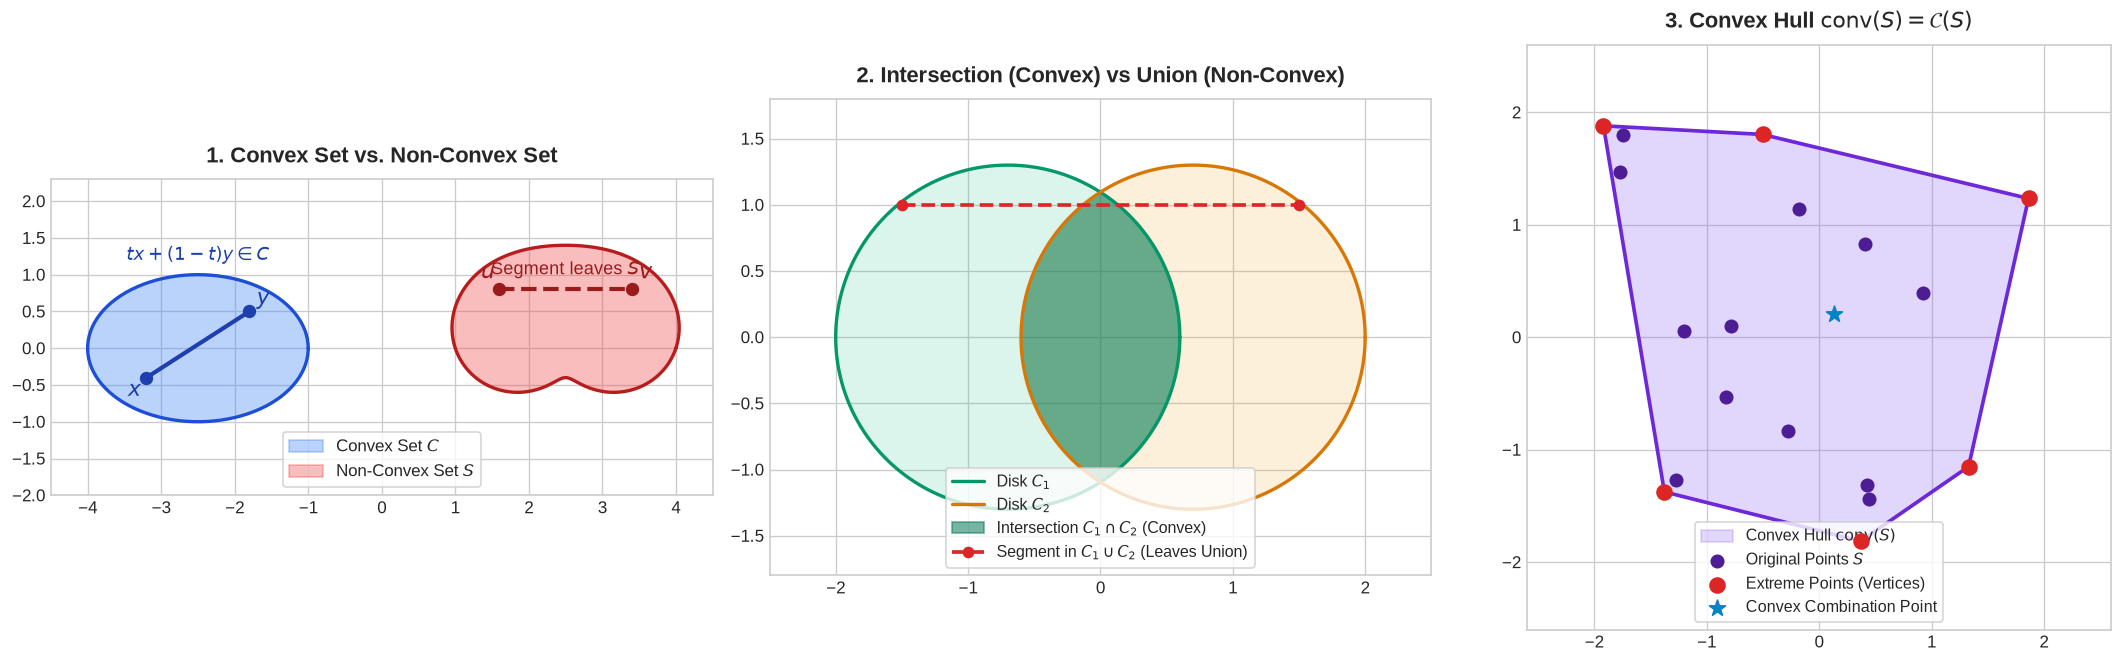

In [3]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# Set high quality plot styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=120)

# -----------------------------------------------------
# Panel 1: Convex Set vs. Non-Convex Set
# -----------------------------------------------------
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 200)
# Convex ellipse
xc = 1.5 * np.cos(theta) - 2.5
yc = 1.0 * np.sin(theta)
ax.fill(xc, yc, color='#3b82f6', alpha=0.35, label='Convex Set $C$')
ax.plot(xc, yc, color='#1d4ed8', lw=2)

# Segment in Convex set
p1 = np.array([-3.2, -0.4])
p2 = np.array([-1.8, 0.5])
ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'o-', color='#1e40af', lw=2.5, markersize=7)
ax.text(p1[0]-0.25, p1[1]-0.25, '$x$', fontsize=13, fontweight='bold', color='#1e40af')
ax.text(p2[0]+0.1, p2[1]+0.1, '$y$', fontsize=13, fontweight='bold', color='#1e40af')
ax.text(-2.5, 1.2, '$tx + (1-t)y \in C$', fontsize=11, color='#1e40af', ha='center')

# Non-convex crescent / kidney shape
r_nc = 1.2 + 0.5 * np.sin(theta) + 0.3 * np.cos(2*theta)
x_nc = r_nc * np.cos(theta) + 2.5
y_nc = r_nc * np.sin(theta)
ax.fill(x_nc, y_nc, color='#ef4444', alpha=0.35, label='Non-Convex Set $S$')
ax.plot(x_nc, y_nc, color='#b91c1c', lw=2)

# Segment in Non-convex set (violating convexity)
q1 = np.array([1.6, 0.8])
q2 = np.array([3.4, 0.8])
ax.plot([q1[0], q2[0]], [q1[1], q2[1]], 'o--', color='#991b1b', lw=2.5, markersize=7)
ax.text(q1[0]-0.25, q1[1]+0.15, '$u$', fontsize=13, fontweight='bold', color='#991b1b')
ax.text(q2[0]+0.1, q2[1]+0.15, '$v$', fontsize=13, fontweight='bold', color='#991b1b')
ax.text(2.5, 1.0, 'Segment leaves $S$', fontsize=11, color='#991b1b', ha='center')

ax.set_title('1. Convex Set vs. Non-Convex Set', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-2.0, 2.3)
ax.legend(loc='lower center', frameon=True)
ax.set_aspect('equal')

# -----------------------------------------------------
# Panel 2: Intersection (Convex) vs. Union (Non-Convex)
# -----------------------------------------------------
ax = axes[1]
c1_x, c1_y = -0.7, 0.0
c2_x, c2_y = 0.7, 0.0
r = 1.3

d1_x = c1_x + r * np.cos(theta)
d1_y = c1_y + r * np.sin(theta)
d2_x = c2_x + r * np.cos(theta)
d2_y = c2_y + r * np.sin(theta)

# Plot outlines
ax.plot(d1_x, d1_y, color='#059669', lw=2, label='Disk $C_1$')
ax.plot(d2_x, d2_y, color='#d97706', lw=2, label='Disk $C_2$')

# Fill union light gray
ax.fill(d1_x, d1_y, color='#10b981', alpha=0.15)
ax.fill(d2_x, d2_y, color='#f59e0b', alpha=0.15)

# Fill intersection shaded green/blue
phi = np.linspace(-np.arccos(c2_x/r), np.arccos(c2_x/r), 100)
ix1 = c1_x + r * np.cos(phi)
iy1 = c1_y + r * np.sin(phi)
ix2 = c2_x - r * np.cos(phi)
iy2 = c2_y + r * np.sin(phi)
inter_x = np.concatenate([ix1, ix2[::-1]])
inter_y = np.concatenate([iy1, iy2[::-1]])
ax.fill(inter_x, inter_y, color='#047857', alpha=0.55, label='Intersection $C_1 \cap C_2$ (Convex)')

# Non-convex union segment
ux = np.array([-1.5, 1.5])
uy = np.array([1.0, 1.0])
ax.plot(ux, uy, 'o--', color='#dc2626', lw=2.2, label='Segment in $C_1 \cup C_2$ (Leaves Union)')

ax.set_title('2. Intersection (Convex) vs Union (Non-Convex)', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.8, 1.8)
ax.legend(loc='lower center', fontsize=9.5, frameon=True)
ax.set_aspect('equal')

# -----------------------------------------------------
# Panel 3: Convex Hull of Random Points in 2D
# -----------------------------------------------------
ax = axes[2]
np.random.seed(42)
points = np.random.uniform(-2, 2, (18, 2))
hull = ConvexHull(points)

# Fill convex hull
hull_points = points[hull.vertices]
ax.fill(hull_points[:, 0], hull_points[:, 1], color='#8b5cf6', alpha=0.25, label='Convex Hull $\mathrm{conv}(S)$')
for simplex in hull.simplices:
    ax.plot(points[simplex, 0], points[simplex, 1], color='#6d28d9', lw=2.2)

# Scatter all points
ax.scatter(points[:, 0], points[:, 1], color='#4c1d95', s=55, zorder=5, label='Original Points $S$')
ax.scatter(hull_points[:, 0], hull_points[:, 1], color='#dc2626', s=80, zorder=6, label='Extreme Points (Vertices)')

# Highlight a convex combination of 3 vertices
v1, v2, v3 = hull_points[0], hull_points[2], hull_points[4]
combo = 0.3 * v1 + 0.4 * v2 + 0.3 * v3
ax.scatter([combo[0]], [combo[1]], color='#0284c7', s=100, marker='*', zorder=7, label='Convex Combination Point')

ax.set_title('3. Convex Hull $\mathrm{conv}(S) = \mathcal{C}(S)$', fontsize=13, fontweight='bold', pad=10)
ax.set_xlim(-2.6, 2.6)
ax.set_ylim(-2.6, 2.6)
ax.legend(loc='lower center', fontsize=9.5, frameon=True)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()
